# ***Start***

### ***Import Libraries***

In [1549]:
import numpy as np

import pandas as pd

import seaborn as sns

import plotly

import sklearn
from sklearn.preprocessing import MinMaxScaler

import mplsoccer as mpl
from mplsoccer import Pitch

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap

### ***Notebook Settings***

In [1550]:
pd.set_option('display.max_columns', None)  # Show all columns
"""
pd.set_option('display.max_rows', None)     # Show all rows (optional, careful if very large!)
pd.set_option('display.max_colwidth', None) # Optional: expand the column width
pd.set_option('display.width', 200) # Optional: display width to prevent wrapping
"""

"\npd.set_option('display.max_rows', None)     # Show all rows (optional, careful if very large!)\npd.set_option('display.max_colwidth', None) # Optional: expand the column width\npd.set_option('display.width', 200) # Optional: display width to prevent wrapping\n"

### ***Import Data***

In [1551]:
data = pd.read_excel("data/clean_EDA_data.xlsx")
data.head()

,x,y,IndividualPlay,RegularPlay,LeftFoot,RightFoot,FromCorner,FirstTouch,Head,SetPiece,Volley,FastBreak,ThrowinSetPiece,Penalty,OneOnOne,KeyPass,DirectFreekick,OtherBodyPart,period_FirstHalf,period_SecondHalf,Zone_Back,Zone_Center,Zone_Left,Zone_Right,is_goal,Norm_E_dis,Norm_Theta,ChanceQuality,Assisted
0,80.8,51.6,True,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,0.249773,0.120483,0.485309,True
1,79.3,24.2,True,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,0.428775,0.059867,0.401301,True
2,80.0,59.5,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,0.286973,0.100720,0.464268,True
3,89.8,55.6,False,False,False,False,True,True,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,0.150875,0.190062,0.549768,True
4,84.9,56.2,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,0.211536,0.137936,0.505507,True


# ***Feature Reduction***

### ***Feature Reduction: Remove Trivial/Repetative Features***

In [1552]:
data.columns

Index(['x', 'y', 'IndividualPlay', 'RegularPlay', 'LeftFoot', 'RightFoot',
       'FromCorner', 'FirstTouch', 'Head', 'SetPiece', 'Volley', 'FastBreak',
       'ThrowinSetPiece', 'Penalty', 'OneOnOne', 'KeyPass', 'DirectFreekick',
       'OtherBodyPart', 'period_FirstHalf', 'period_SecondHalf', 'Zone_Back',
       'Zone_Center', 'Zone_Left', 'Zone_Right', 'is_goal', 'Norm_E_dis',
       'Norm_Theta', 'ChanceQuality', 'Assisted'],
      dtype='str')

- ***'LeftFoot' and 'RightFoot' are Inverse Boolean features so I will only keep one and remove 'LeftFoot'.***
- ***'period_FirstHalf' and 'period_SecondHalf' are Inverse Boolean features so I will only keep one and remove 'period_SecondHalf'.***
- ***'Zone_Back', 'Zone_Center', 'Zone_Left', and 'Zone_Right' are coarse categorizations of 'x', 'y', so I will remove them for the modeling stage.***

In [1553]:
data.drop(columns=['LeftFoot', 'period_SecondHalf', 'Zone_Back', 'Zone_Center', 'Zone_Left', 'Zone_Right'], inplace=True)

data.head()

,x,y,IndividualPlay,RegularPlay,RightFoot,FromCorner,FirstTouch,Head,SetPiece,Volley,FastBreak,ThrowinSetPiece,Penalty,OneOnOne,KeyPass,DirectFreekick,OtherBodyPart,period_FirstHalf,is_goal,Norm_E_dis,Norm_Theta,ChanceQuality,Assisted
0,80.8,51.6,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,0.249773,0.120483,0.485309,True
1,79.3,24.2,True,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,0.428775,0.059867,0.401301,True
2,80.0,59.5,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,0.286973,0.100720,0.464268,True
3,89.8,55.6,False,False,False,True,True,True,False,False,False,False,False,False,False,False,False,False,False,0.150875,0.190062,0.549768,True
4,84.9,56.2,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,0.211536,0.137936,0.505507,True


### ***Feature Reduction: Remove Collinear/Irrelevant Variables***

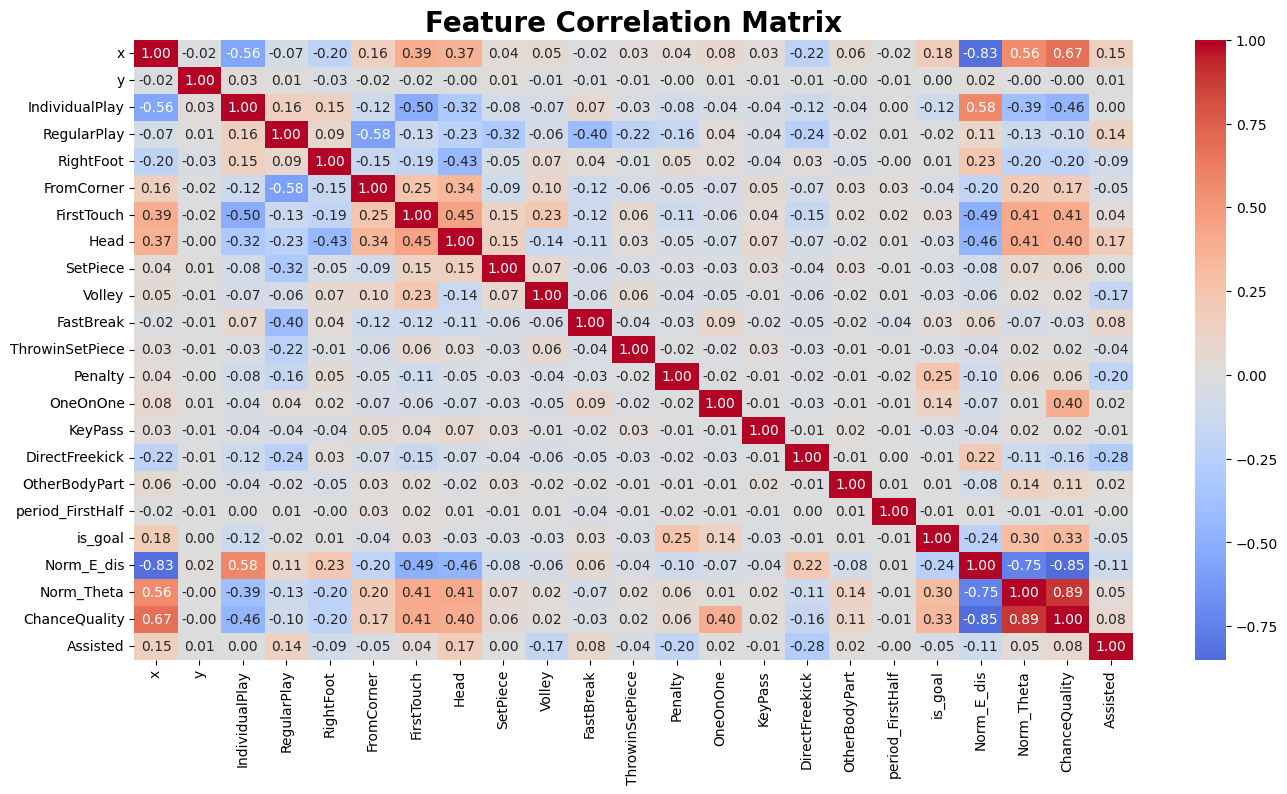

In [1554]:
corr_matrix = data.corr()
num_cells = len(corr_matrix)

plt.figure(figsize=(0.7*num_cells, 0.35*num_cells))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Feature Correlation Matrix", fontsize=20, fontweight='bold')
plt.show()

In [1555]:
collinear_features = ['Norm_E_dis', 'Norm_Theta', 'OneOnOne'] 

In [1556]:
corr_with_target = data.corr()['is_goal']
low_effect = corr_with_target[abs(corr_with_target) < 0.025]

low_effect_features = corr_with_target[abs(corr_with_target) < 0.025].index.tolist()
low_effect_features.remove('y')

low_effect_features

['RegularPlay',
 'RightFoot',
 'DirectFreekick',
 'OtherBodyPart',
 'period_FirstHalf']

In [1557]:
data.drop(columns=collinear_features + low_effect_features, inplace=True)

data.head()

,x,y,IndividualPlay,FromCorner,FirstTouch,Head,SetPiece,Volley,FastBreak,ThrowinSetPiece,Penalty,KeyPass,is_goal,ChanceQuality,Assisted
0,80.8,51.6,True,False,False,False,False,False,False,False,False,False,False,0.485309,True
1,79.3,24.2,True,False,False,False,False,False,False,False,False,False,False,0.401301,True
2,80.0,59.5,False,True,False,False,False,False,False,False,False,False,False,0.464268,True
3,89.8,55.6,False,True,True,True,False,False,False,False,False,False,False,0.549768,True
4,84.9,56.2,False,False,False,False,False,False,False,False,False,False,False,0.505507,True


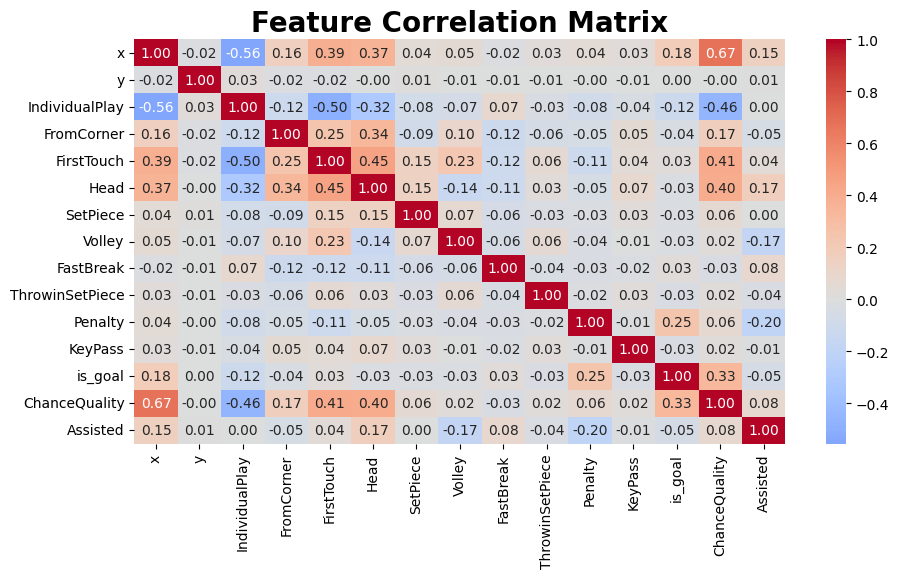

In [1590]:
corr_matrix = data.corr()
num_cells = len(corr_matrix)

plt.figure(figsize=(0.7*num_cells, 0.35*num_cells))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Feature Correlation Matrix", fontsize=20, fontweight='bold')
plt.show()

# ***Data Preparation***

In [1559]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss, roc_auc_score, brier_score_loss

In [1560]:
pitch = Pitch(pitch_type='opta')

In [1561]:
X = data.drop('is_goal', axis=1)
Y = data['is_goal']

In [1562]:
X.head()

,x,y,IndividualPlay,FromCorner,FirstTouch,Head,SetPiece,Volley,FastBreak,ThrowinSetPiece,Penalty,KeyPass,ChanceQuality,Assisted
0,80.8,51.6,True,False,False,False,False,False,False,False,False,False,0.485309,True
1,79.3,24.2,True,False,False,False,False,False,False,False,False,False,0.401301,True
2,80.0,59.5,False,True,False,False,False,False,False,False,False,False,0.464268,True
3,89.8,55.6,False,True,True,True,False,False,False,False,False,False,0.549768,True
4,84.9,56.2,False,False,False,False,False,False,False,False,False,False,0.505507,True


In [1563]:
Y.head()

0    False
1    False
2    False
3    False
4    False
Name: is_goal, dtype: bool

In [1564]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [1565]:
final_df = X_test.copy()

# ***Models***

## ***Logistic Regression Model***

In [1566]:
from sklearn.linear_model import LogisticRegression

In [1567]:
model_LogReg = LogisticRegression(max_iter=1000)

In [1568]:
model_LogReg.fit(X_train, Y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [1569]:
Y_LogReg_XG = model_LogReg.predict_proba(X_test)[:, 1]

In [1570]:
final_df['LogReg_XG'] = Y_LogReg_XG
final_df.sort_values('LogReg_XG', ascending=False).head()

,x,y,IndividualPlay,FromCorner,FirstTouch,Head,SetPiece,Volley,FastBreak,ThrowinSetPiece,Penalty,KeyPass,ChanceQuality,Assisted,LogReg_XG
970,98.2,52.1,False,False,True,False,False,False,False,False,False,False,0.989229,True,0.890574
7350,97.3,49.7,False,False,False,False,False,False,True,False,False,False,0.957254,True,0.884966
3985,97.2,49.6,False,False,True,False,False,False,False,False,False,False,0.915890,False,0.835106
7938,97.3,50.4,False,False,True,False,False,True,False,False,False,False,0.953010,False,0.820164
3165,88.5,50.0,False,False,False,False,False,False,False,False,True,False,0.555966,False,0.793013


In [1571]:
logloss_LogReg = log_loss(Y_test, Y_LogReg_XG)
roc_auc_LogReg = roc_auc_score(Y_test, Y_LogReg_XG)
brier_score_LogReg = brier_score_loss(Y_test, Y_LogReg_XG)

print(f"Log Loss: {logloss_LogReg}")
print(f"ROC AUC: {roc_auc_LogReg}")
print(f"Brier Score: {brier_score_LogReg}")

Log Loss: 0.2938571959658124
ROC AUC: 0.7782751139551191
Brier Score: 0.08334451268463886


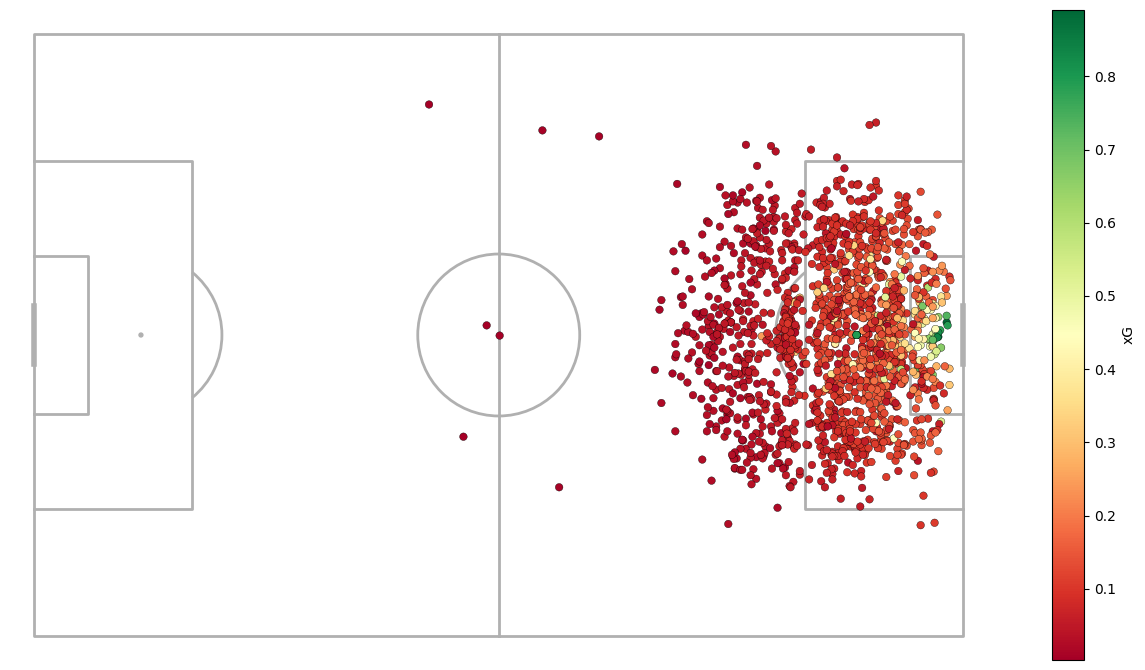

In [1572]:
fig, ax = pitch.draw(figsize=(10.5*1.25, 6.8*1))

sc = pitch.scatter(
    final_df['x'], final_df['y'],                           # Shot coordinates
    c=final_df['LogReg_XG'],                                # XG for color
    cmap='RdYlGn',
    edgecolors='black', linewidth=0.25, s=30, alpha=1,      # Point styling
    ax=ax
    )

plt.colorbar(sc, ax=ax, label='xG')

## ***Decision Tree Regressor***

In [1573]:
from sklearn.tree import DecisionTreeRegressor

In [1574]:
model_dtReg = DecisionTreeRegressor(max_depth=5, min_samples_leaf=50)

In [1575]:
model_dtReg.fit(X_train, Y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",50
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_l

In [1576]:
Y_dtReg_XG = model_dtReg.predict(X_test)

In [1577]:
final_df['dtReg_XG'] = Y_dtReg_XG
final_df.sort_values('dtReg_XG', ascending=False).head()

,x,y,IndividualPlay,FromCorner,FirstTouch,Head,SetPiece,Volley,FastBreak,ThrowinSetPiece,Penalty,KeyPass,ChanceQuality,Assisted,LogReg_XG,dtReg_XG
381,88.5,50.0,False,False,False,False,False,False,False,False,True,False,0.555966,False,0.793013,0.821429
7360,88.5,50.0,False,False,False,False,False,False,False,False,True,False,0.555966,False,0.793013,0.821429
1321,88.5,50.0,False,False,False,False,False,False,False,False,True,False,0.555966,False,0.793013,0.821429
3944,88.5,50.0,False,False,False,False,False,False,False,False,True,False,0.555966,False,0.793013,0.821429
2966,88.5,50.0,False,False,False,False,False,False,False,False,True,False,0.555966,False,0.793013,0.821429


In [1578]:
logloss_dtReg = log_loss(Y_test, Y_dtReg_XG)
roc_auc_dtReg = roc_auc_score(Y_test, Y_dtReg_XG)
brier_score_dtReg = brier_score_loss(Y_test, Y_dtReg_XG)

print(f"Log Loss: {logloss_dtReg}")
print(f"ROC AUC: {roc_auc_dtReg}")
print(f"Brier Score: {brier_score_dtReg}")

Log Loss: 0.2987789110873698
ROC AUC: 0.7574983929406265
Brier Score: 0.0847575221565821


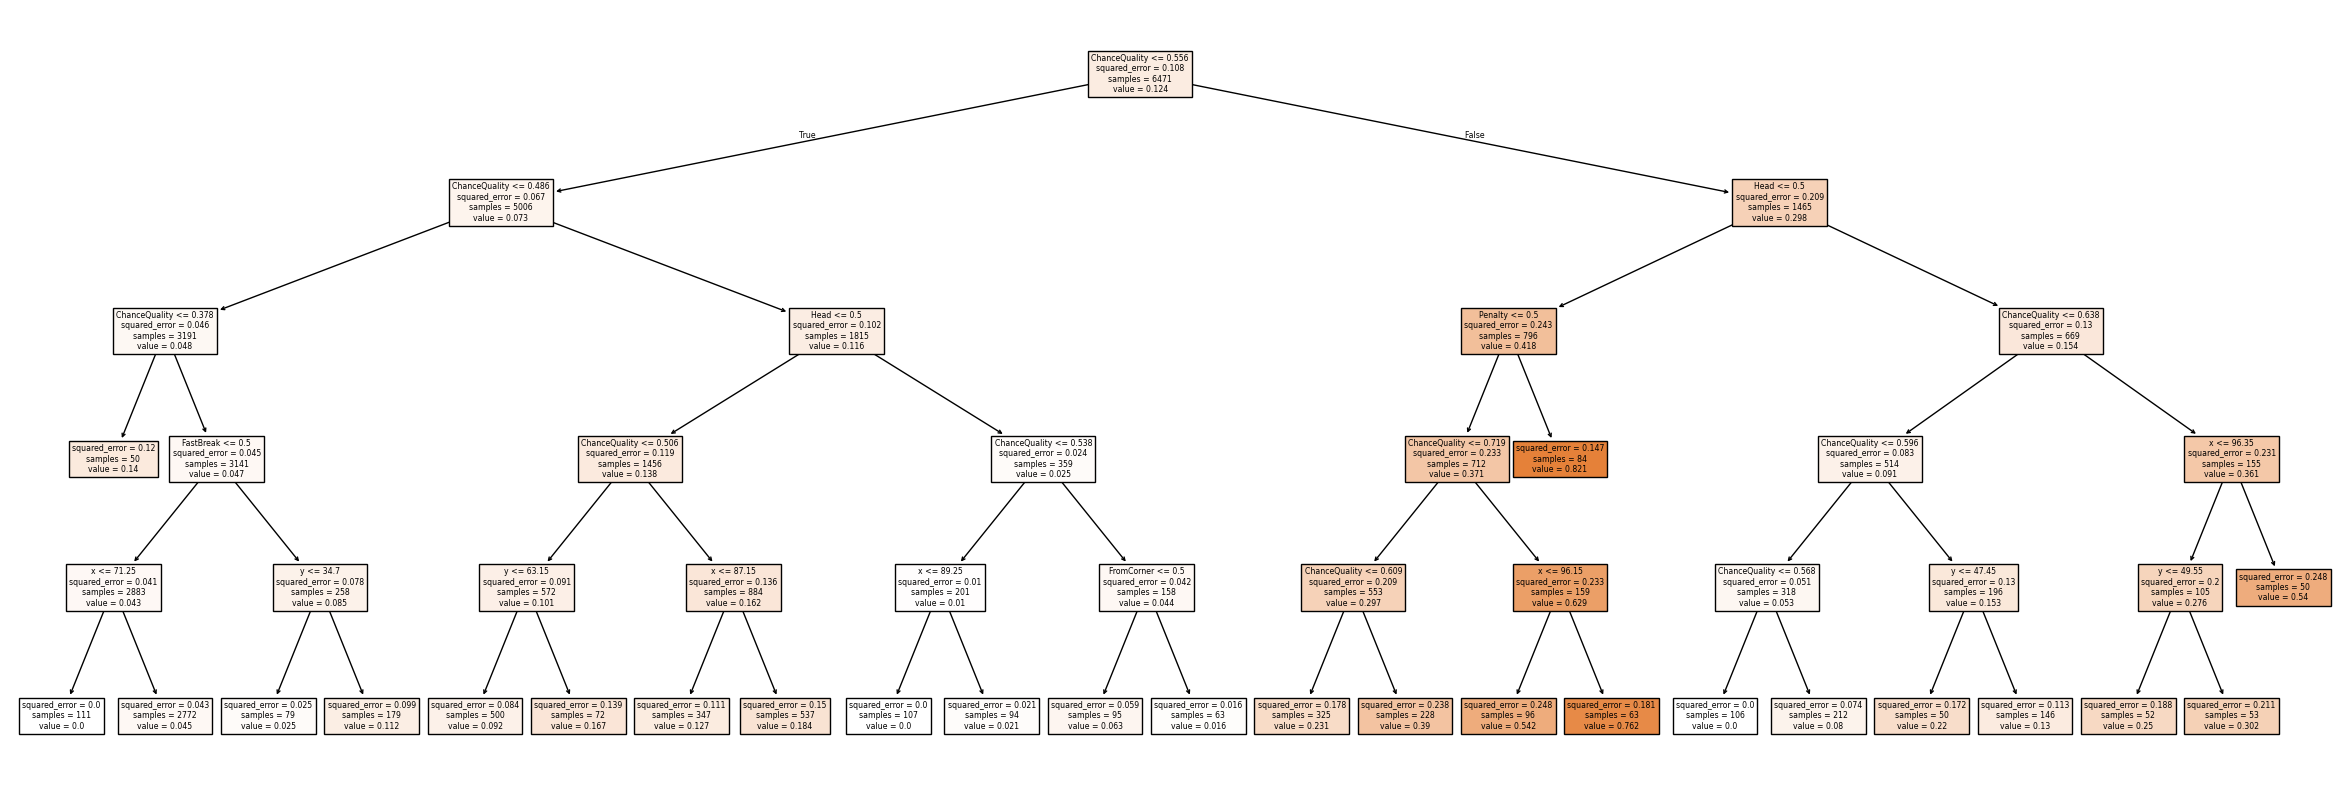

In [1579]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(30,10))
plot_tree(model_dtReg, feature_names=X.columns, filled=True)
plt.show()

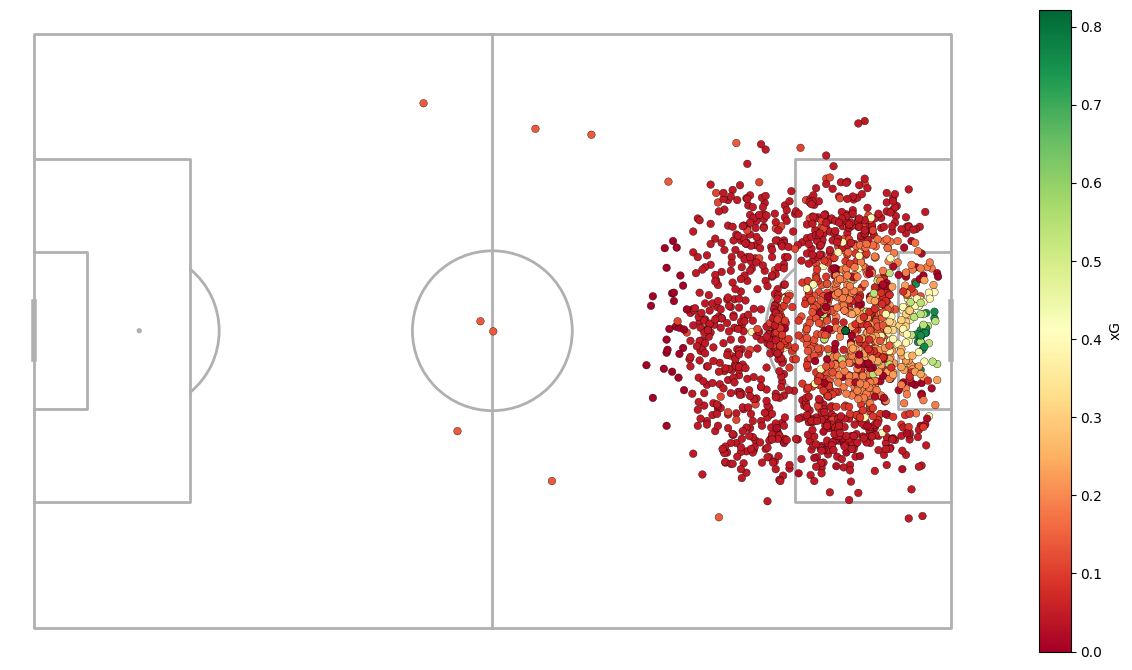

In [1580]:
fig, ax = pitch.draw(figsize=(10.5*1.25, 6.8*1))

sc = pitch.scatter(
    final_df['x'], final_df['y'],                         # Shot coordinates
    c=final_df['dtReg_XG'],                                # XG for color
    cmap='RdYlGn',
    edgecolors='black', linewidth=0.25, s=30, alpha=1,      # Point styling
    ax=ax
    )

plt.colorbar(sc, ax=ax, label='xG')

## ***RandomForest Regressor***

In [1581]:
from sklearn.ensemble import RandomForestRegressor

In [1582]:
model_rfReg = RandomForestRegressor(n_estimators=100, max_depth=6, min_samples_leaf=50, random_state=42, n_jobs=-1)

In [1583]:
model_rfReg.fit(X_train, Y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",50
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [1584]:
importance = pd.Series(model_rfReg.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(5)

ChanceQuality    0.635028
Penalty          0.168611
Head             0.090609
x                0.057094
y                0.026686
dtype: float64

In [1585]:
Y_rfReg_XG = model_rfReg.predict(X_test)

In [1586]:
final_df['rfReg_XG'] = Y_rfReg_XG
final_df.sort_values('rfReg_XG', ascending=False).head()

,x,y,IndividualPlay,FromCorner,FirstTouch,Head,SetPiece,Volley,FastBreak,ThrowinSetPiece,Penalty,KeyPass,ChanceQuality,Assisted,LogReg_XG,dtReg_XG,rfReg_XG
3944,88.5,50.0,False,False,False,False,False,False,False,False,True,False,0.555966,False,0.793013,0.821429,0.798016
7360,88.5,50.0,False,False,False,False,False,False,False,False,True,False,0.555966,False,0.793013,0.821429,0.798016
3165,88.5,50.0,False,False,False,False,False,False,False,False,True,False,0.555966,False,0.793013,0.821429,0.798016
473,88.5,50.0,False,False,False,False,False,False,False,False,True,False,0.555966,False,0.793013,0.821429,0.798016
381,88.5,50.0,False,False,False,False,False,False,False,False,True,False,0.555966,False,0.793013,0.821429,0.798016


In [1587]:
logloss = log_loss(Y_test, Y_rfReg_XG)
roc_auc = roc_auc_score(Y_test, Y_rfReg_XG)
brier_score = brier_score_loss(Y_test, Y_rfReg_XG)

print(f"Log Loss: {logloss}")
print(f"ROC AUC: {roc_auc}")
print(f"Brier Score: {brier_score}")

Log Loss: 0.2951066729708412
ROC AUC: 0.7846193460729313
Brier Score: 0.08420494200573976


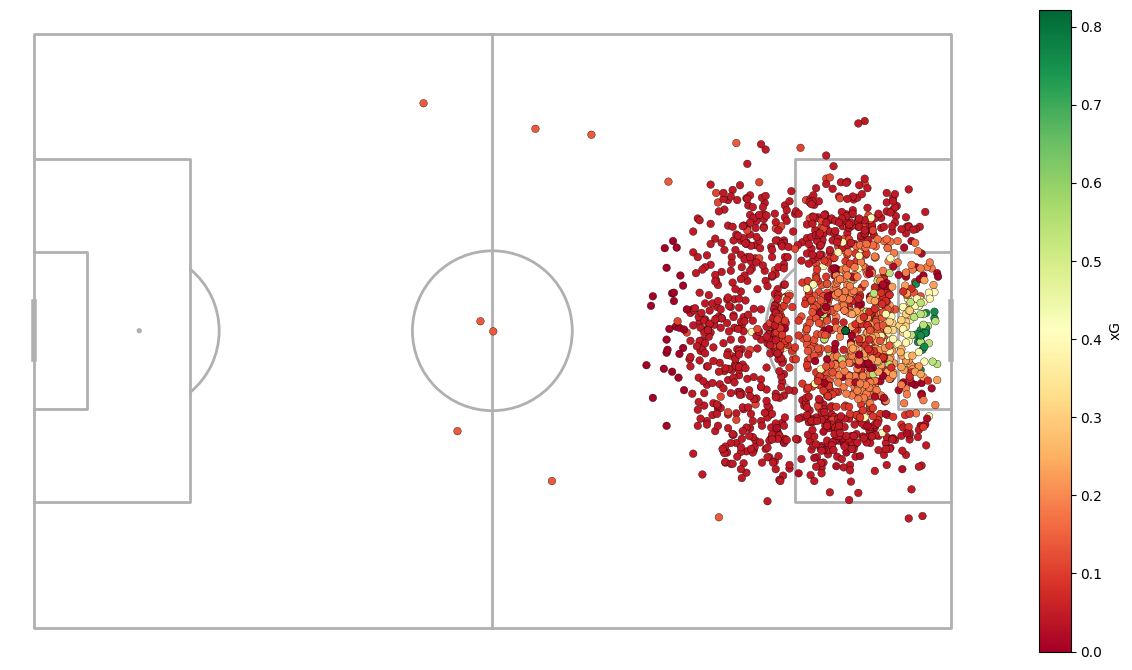

In [1588]:
fig, ax = pitch.draw(figsize=(10.5*1.25, 6.8*1))

sc = pitch.scatter(
    final_df['x'], final_df['y'],                           # Shot coordinates
    c=final_df['dtReg_XG'],                                 # XG for color
    cmap='RdYlGn',
    edgecolors='black', linewidth=0.25, s=30, alpha=1,      # Point styling
    ax=ax
    )

plt.colorbar(sc, ax=ax, label='xG')

## ***XGBoost Model***